In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [12]:
train = pd.read_csv('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/sales_churn_train.csv')
test = pd.read_csv('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/sales_churn_test.csv')
clientes = pd.read_csv('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/Clientes.csv')
coolers = pd.read_csv('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/Coolers.csv')

print(train.shape, test.shape, clientes.shape, coolers.shape)

(5030534, 5) (199923, 4) (371727, 4) (4636676, 4)


In [14]:
print(train['target'].value_counts())
print(round(train['target'].mean()*100, 2), '%')

target
0    4987132
1      43402
Name: count, dtype: int64
0.86 %


In [15]:
print(train.isnull().sum())
print(clientes.isnull().sum())
print(coolers.isnull().sum())

customer_id          0
calmonth             0
num_transacciones    0
uni_boxes_sold_m     0
target               0
dtype: int64
customer_id                   0
territory_d                   0
comercial_subchannel_d        0
rtm_customer_size_d       15438
dtype: int64
customer_id    0
calmonth       0
num_coolers    0
num_doors      0
dtype: int64


In [16]:
coolers_last = coolers.sort_values('calmonth').groupby('customer_id').last().reset_index()
df = train.merge(clientes, on='customer_id', how='left')
df = df.merge(coolers_last[['customer_id','num_coolers','num_doors']], on='customer_id', how='left')
print(df.shape)

(5030534, 10)


In [17]:
for col in ['num_transacciones', 'uni_boxes_sold_m', 'num_coolers', 'num_doors']:
    si = df[df['target']==1][col].mean()
    no = df[df['target']==0][col].mean()
    print(f"{col}: churn={round(si,2)} no_churn={round(no,2)}")

num_transacciones: churn=0.04 no_churn=95.55
uni_boxes_sold_m: churn=-0.0 no_churn=250.06
num_coolers: churn=1.19 no_churn=1.56
num_doors: churn=1.61 no_churn=2.36


territory_d
Monclova            0.013461
Reynosa             0.013077
Guadalajara         0.011331
Matamoros           0.011148
Laredo              0.011061
Saltillo            0.011052
San Luis Potosi     0.010348
Comarca Lagunera    0.010075
Piedras negras      0.009575
Monterrey           0.009484
Name: target, dtype: float64


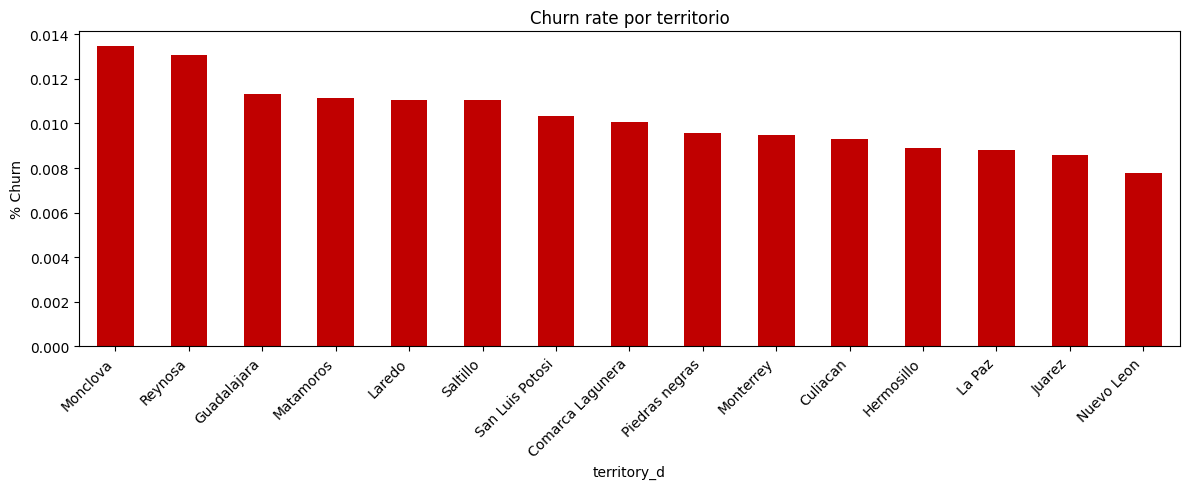

In [20]:
churn_terr = df.groupby('territory_d')['target'].mean().sort_values(ascending=False)
print(churn_terr.head(10))

plt.figure(figsize=(12,5))
churn_terr.head(15).plot(kind='bar', color='#C00000')
plt.title('Churn rate por territorio')
plt.ylabel('% Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/churn_territorio.png')
plt.show()

cooler_grupo
0-1    0.007343
2      0.003042
3-5    0.001445
6+     0.000494
Name: target, dtype: float64


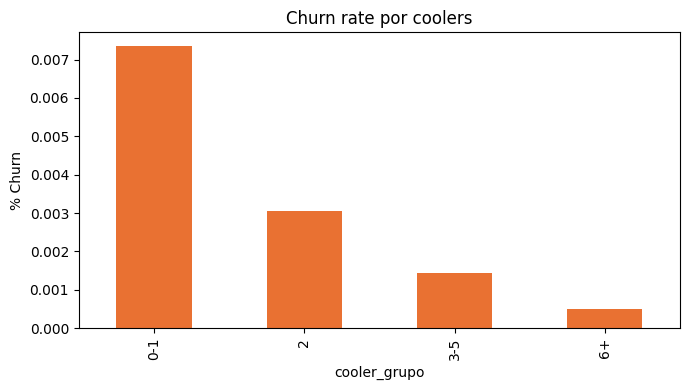

In [21]:
df['cooler_grupo'] = pd.cut(df['num_coolers'], bins=[0,1,2,5,100], labels=['0-1','2','3-5','6+'])
churn_coolers = df.groupby('cooler_grupo')['target'].mean()
print(churn_coolers)

plt.figure(figsize=(7,4))
churn_coolers.plot(kind='bar', color='#E97132')
plt.title('Churn rate por coolers')
plt.ylabel('% Churn')
plt.tight_layout()
plt.savefig('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/churn_coolers.png')
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

#features de comportamiento
df_model['promedio_cajas'] = df_model['uni_boxes_sold_m'] / (df_model['num_transacciones'] + 1)
df_model['cajas_por_puerta'] = df_model['uni_boxes_sold_m'] / (df_model['num_doors'] + 1)

#encode categoricas
le = LabelEncoder()
df_model['territory_enc'] = le.fit_transform(df_model['territory_d'].astype(str))
df_model['subchannel_enc'] = le.fit_transform(df_model['comercial_subchannel_d'].astype(str))
df_model['size_enc'] = le.fit_transform(df_model['rtm_customer_size_d'].astype(str))

df_model['num_coolers'] = df_model['num_coolers'].fillna(0)
df_model['num_doors'] = df_model['num_doors'].fillna(0)

print(df_model.shape)

(5030534, 16)


In [25]:
features = ['num_transacciones', 'uni_boxes_sold_m', 'num_coolers', 'num_doors',
            'promedio_cajas', 'cajas_por_puerta', 'territory_enc', 'subchannel_enc', 'size_enc']

X = df_model[features]
y = df_model['target']

print(X.shape, y.value_counts())

(5030534, 9) target
0    4987132
1      43402
Name: count, dtype: int64


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)

print("entrenado")

entrenado


In [35]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    997389
           1       0.72      0.99      0.84      8718

    accuracy                           1.00   1006107
   macro avg       0.86      0.99      0.92   1006107
weighted avg       1.00      1.00      1.00   1006107

AUC: 0.9987


uni_boxes_sold_m     0.433744
promedio_cajas       0.244975
num_transacciones    0.236013
cajas_por_puerta     0.060166
size_enc             0.019487
num_coolers          0.004656
num_doors            0.000684
territory_enc        0.000186
subchannel_enc       0.000090
dtype: float64


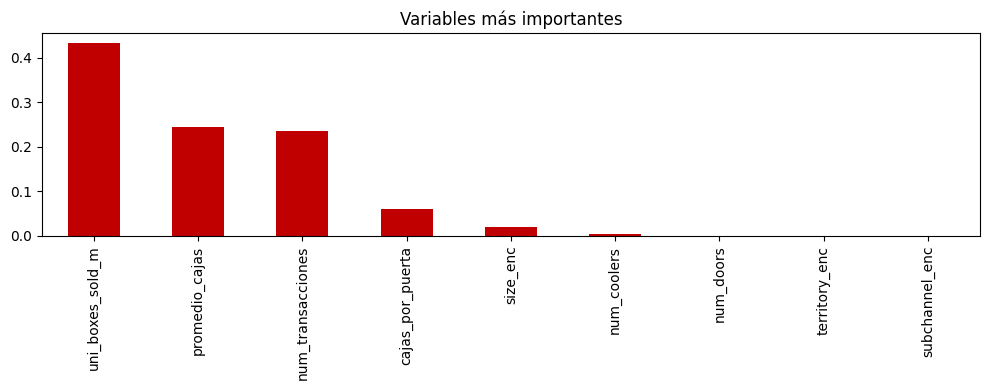

In [40]:
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importancias)

importancias.plot(kind='bar', color='#C00000', figsize=(10,4))
plt.title('Variables más importantes')
plt.tight_layout()
plt.savefig('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/feature_importance.png')
plt.show()

In [41]:
test_model = test.merge(clientes, on='customer_id', how='left')
test_model = test_model.merge(coolers_last[['customer_id','num_coolers','num_doors']], on='customer_id', how='left')

test_model['promedio_cajas'] = test_model['uni_boxes_sold_m'] / (test_model['num_transacciones'] + 1)
test_model['cajas_por_puerta'] = test_model['uni_boxes_sold_m'] / (test_model['num_doors'] + 1)

test_model['territory_enc'] = le.transform(test_model['territory_d'].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0]))
test_model['subchannel_enc'] = le.transform(test_model['comercial_subchannel_d'].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0]))
test_model['size_enc'] = le.transform(test_model['rtm_customer_size_d'].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0]))

test_model[features] = test_model[features].fillna(0)

print(test_model.shape)

(199923, 14)


In [42]:
probas = model.predict_proba(test_model[features])[:,1]
preds = (probas >= 0.5).astype(int)

submission = pd.read_csv('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/preds_submission.csv')
submission['target'] = preds

submission['risk_level'] = pd.cut(probas, bins=[0, 0.4, 0.7, 1.0], labels=['bajo', 'medio', 'alto'])

submission.to_csv('/Users/samanthaabigailsaucedatrevino/hackathon-churn/data/preds_submission_final.csv', index=False)
print(submission['target'].value_counts())
print(submission['risk_level'].value_counts())

target
0    197388
1      2535
Name: count, dtype: int64
risk_level
alto     2519
medio      19
bajo        8
Name: count, dtype: int64


In [43]:
import pickle

with open('/Users/samanthaabigailsaucedatrevino/hackathon-churn/model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('/Users/samanthaabigailsaucedatrevino/hackathon-churn/model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("modelos guardados")

modelos guardados
